# Financial Modelling: Baseline ARX

This notebook implements baseline ARX (AutoRegressive with eXogenous variables) models for predicting asset returns using only:
- **AR lags**: Past returns of the target asset
- **Macro-financial controls**: EUR/USD, USD/CNY exchange rates, oil prices, 10Y Treasury yield

No emotion/social indices are included - this serves as the baseline for comparison with enhanced models.

## Evaluation Metrics
- **MAE** (Mean Absolute Error): Primary metric
- **RMSE** (Root Mean Squared Error): Secondary metric
- **Cumulative Returns**: Strategy performance vs buy-and-hold

In [3]:
# Configuration
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

# Set display options
plt.rcParams.update({'font.size': 12, 'figure.figsize': (12, 6)})
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Project paths
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = DATA_DIR / 'fm_prelim'
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling
Output directory: /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim


In [5]:
# Import custom modules
from modules.finance.models.arx import (
    LagSpec, 
    automl_group_arx, 
    make_group_arx_supervised,
    run_three_assets_on_returns
)
from modules.finance.evaluation.metrics import (
    compute_all_metrics,
    bootstrap_coefficient_ci,
    compare_cv_methods
)
from modules.finance.visualisation.feature_importance import (
    plot_coefficient_importance,
    plot_model_comparison_bars
)

print("Modules imported successfully")

Modules imported successfully


## Load Data

Load the financial returns dataset with controls. Target variables are:
- `r_btc`: Bitcoin daily returns
- `r_gold`: Gold daily returns  
- `r_spx`: S&P 500 daily returns

Control variables:
- `dln_eurusd`: EUR/USD log changes
- `dln_usdcny`: USD/CNY log changes
- `dln_oil`: Oil price log changes
- `dy10`: 10-year Treasury yield changes

In [7]:
# Load financial data
df = pd.read_csv(DATA_DIR / 'financial_returns_and_controls.csv', index_col=0, parse_dates=True)
df = df.sort_index()

# Define target and control columns
TARGET_COLS = ['r_btc', 'r_gold', 'r_spx']
CONTROL_COLS = ['dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10']

# Forward fill controls to handle missing values
for col in CONTROL_COLS:
    if col in df.columns:
        df[col] = df[col].ffill()

# Drop rows with missing targets
df_clean = df.dropna(subset=TARGET_COLS)

print(f"Data shape: {df_clean.shape}")
print(f"Date range: {df_clean.index.min()} to {df_clean.index.max()}")
print(f"\nTarget columns: {TARGET_COLS}")
print(f"Control columns: {CONTROL_COLS}")
print(f"\nMissing values per column:")
print(df_clean[TARGET_COLS + CONTROL_COLS].isna().sum())

Data shape: (108, 7)
Date range: 2025-01-01 00:00:00 to 2025-05-30 00:00:00

Target columns: ['r_btc', 'r_gold', 'r_spx']
Control columns: ['dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10']

Missing values per column:
r_btc         0
r_gold        0
r_spx         0
dln_eurusd    0
dln_usdcny    0
dln_oil       0
dy10          0
dtype: int64


## Baseline ARX Configuration

Define the baseline model specification with:
- AR lags to optimize: range [1, 5]
- Control lags to optimize: range [0, 3]
- **No emotion indices** (all q_* set to 0)
- Cross-asset lags: 0 (univariate model)

In [8]:
# Baseline configuration - NO emotion indices
BASELINE_CONFIG = {
    # AR and control lag ranges to optimize
    'p_range': (1, 5),          # AR lags
    'q_control_range': (0, 3),  # Control lags
    
    # All emotion index families set to 0
    'q_ei_range': (0, 0),
    'q_epi_range': (0, 0),
    'q_epi_signed_range': (0, 0),
    'q_ccd_range': (0, 0),
    'q_intensity_range': (0, 0),
    'q_surprise_range': (0, 0),
    'q_split_range': (0, 0),
    
    # No cross-asset spillovers (univariate)
    'q_cross_range': (0, 0),
    
    # Optimization settings
    'n_trials': 300,
    'cv_initial': 60,
    'cv_step': 1,
    'cv_test': 1,
}

print("Baseline ARX Configuration:")
for key, value in BASELINE_CONFIG.items():
    print(f"  {key}: {value}")

Baseline ARX Configuration:
  p_range: (1, 5)
  q_control_range: (0, 3)
  q_ei_range: (0, 0)
  q_epi_range: (0, 0)
  q_epi_signed_range: (0, 0)
  q_ccd_range: (0, 0)
  q_intensity_range: (0, 0)
  q_surprise_range: (0, 0)
  q_split_range: (0, 0)
  q_cross_range: (0, 0)
  n_trials: 300
  cv_initial: 60
  cv_step: 1
  cv_test: 1


## Train Baseline Models

Train separate ARX models for each asset using Optuna optimization with rolling window cross-validation. Compare rolling vs expanding window to select the better CV method.

In [10]:
# Store results for each asset
baseline_results = {}

for target in TARGET_COLS:
    print(f"\n{'='*60}")
    print(f"Training baseline ARX for {target}")
    print('='*60)
    
    # Prepare data - only controls, no emotion indices
    y = df_clean[target]
    controls = df_clean[CONTROL_COLS].fillna(0)
    
    # Run automl optimization
    result = automl_group_arx(
        y=y,
        social=None,  # No emotion indices
        controls=controls,
        cross=None,  # No cross-asset predictors
        p_range=BASELINE_CONFIG['p_range'],
        q_controls_range=BASELINE_CONFIG['q_control_range'],
        q_cross_range=BASELINE_CONFIG['q_cross_range'],
        q_ei_range=BASELINE_CONFIG['q_ei_range'],
        q_epi_range=BASELINE_CONFIG['q_epi_range'],
        q_epi_signed_range=BASELINE_CONFIG['q_epi_signed_range'],
        q_ccd_range=BASELINE_CONFIG['q_ccd_range'],
        q_intensity_range=BASELINE_CONFIG['q_intensity_range'],
        q_surprise_range=BASELINE_CONFIG['q_surprise_range'],
        q_split_range=BASELINE_CONFIG['q_split_range'],
        n_trials=BASELINE_CONFIG['n_trials'],
        initial_train_size=BASELINE_CONFIG['cv_initial'],
        step_size=BASELINE_CONFIG['cv_step'],
        test_size=BASELINE_CONFIG['cv_test'],
    )
    
    # Store results
    baseline_results[target] = {
        'best_lags': result['best_lags'],
        'best_model_params': result['best_model_params'],
        'fitted_pipeline': result['fitted_pipeline'],
        'cv_mae': result['best_score_mae'],
        'cv_rmse': result['best_score_rmse'],
        'coef_sorted': result['coef_sorted'],
        'feature_names': result['feature_names'],
        'X_supervised': result['X_supervised'],
        'y_supervised': result['y_supervised'],
    }
    
    print(f"\nBest specification for {target}:")
    print(f"  AR lags (p): {result['best_lags'].ar_p}")
    print(f"  Control lags (q_controls): {result['best_lags'].q_controls}")
    print(f"  CV MAE: {result['best_score_mae']:.6f}")
    print(f"  CV RMSE: {result['best_score_rmse']:.6f}")

[I 2026-01-24 01:23:17,758] A new study created in memory with name: no-name-3510328a-a64e-48ae-90ba-e0e3e96faa27



Training baseline ARX for r_btc

Best specification for r_btc:
  AR lags (p): 5
  Control lags (q_controls): 0
  CV MAE: 0.019129
  CV RMSE: 0.019129

Training baseline ARX for r_gold

Best specification for r_gold:
  AR lags (p): 3
  Control lags (q_controls): 3
  CV MAE: 0.014541
  CV RMSE: 0.014541

Training baseline ARX for r_spx

Best specification for r_spx:
  AR lags (p): 2
  Control lags (q_controls): 0
  CV MAE: 0.013087
  CV RMSE: 0.013087


In [11]:
# Summary of best specifications
print("\n" + "="*60)
print("BASELINE MODEL SUMMARY")
print("="*60)

summary_data = []
for target, results in baseline_results.items():
    lags = results['best_lags']
    summary_data.append({
        'Asset': target,
        'AR Lags (p)': lags.ar_p,
        'Control Lags (q_controls)': lags.q_controls,
        'CV MAE': results['cv_mae'],
        'CV RMSE': results['cv_rmse'],
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df.style.format({
    'CV MAE': '{:.6f}',
    'CV RMSE': '{:.6f}'
}))


BASELINE MODEL SUMMARY


,Asset,AR Lags (p),Control Lags (q_controls),CV MAE,CV RMSE
0,r_btc,5,0,0.019129,0.019129
1,r_gold,3,3,0.014541,0.014541
2,r_spx,2,0,0.013087,0.013087


## Out-of-Sample Evaluation

Generate out-of-sample predictions using rolling window forecasts and compute evaluation metrics.

In [12]:
# Generate OOS predictions for each asset
oos_predictions = {}
oos_metrics = {}

for target in TARGET_COLS:
    print(f"\nGenerating OOS predictions for {target}...")
    
    lags = baseline_results[target]['best_lags']
    y = df_clean[target]
    controls = df_clean[CONTROL_COLS].fillna(0)
    
    # Build design matrix with optimal lags
    X_design, y_design = make_group_arx_supervised(
        y=y,
        social=None,
        controls=controls,
        cross=None,
        lags=lags
    )
    
    # Rolling window OOS predictions
    y_true_list = []
    y_pred_list = []
    dates_list = []
    
    # Use same CV settings as training
    initial_train = BASELINE_CONFIG['cv_initial']
    step_size = BASELINE_CONFIG['cv_step']
    test_size = BASELINE_CONFIG['cv_test']
    
    n_samples = len(y_design)
    max_lag = max(lags.ar_p, lags.q_controls)
    
    # Get the pipeline and model parameters
    pipeline = baseline_results[target]['fitted_pipeline']
    model_params = baseline_results[target]['best_model_params']
    
    for train_end in range(initial_train, n_samples - test_size + 1, step_size):
        test_start = train_end
        test_end = test_start + test_size
        
        # Train on window
        X_train = X_design.iloc[:train_end].values
        y_train = y_design.iloc[:train_end].values
        
        # Test on next step
        X_test = X_design.iloc[test_start:test_end].values
        y_test = y_design.iloc[test_start:test_end].values
        
        # Clone and fit a new pipeline for each fold
        from sklearn.base import clone
        model = clone(pipeline)
        model.fit(X_train, y_train)
        
        # Predict
        y_pred = model.predict(X_test)
        
        y_true_list.extend(y_test)
        y_pred_list.extend(y_pred)
        dates_list.extend(X_design.index[test_start:test_end].tolist())
    
    # Store predictions
    oos_predictions[target] = pd.DataFrame({
        'date': dates_list,
        'y_true': y_true_list,
        'y_pred': y_pred_list
    }).set_index('date')
    
    # Compute metrics
    oos_metrics[target] = compute_all_metrics(
        np.array(y_true_list), 
        np.array(y_pred_list)
    )
    
    print(f"  OOS samples: {len(y_true_list)}")
    print(f"  OOS MAE: {oos_metrics[target]['mae']:.6f}")
    print(f"  OOS RMSE: {oos_metrics[target]['rmse']:.6f}")
    print(f"  Directional Accuracy: {oos_metrics[target]['dir_acc']:.1f}%")


Generating OOS predictions for r_btc...
  OOS samples: 42
  OOS MAE: 0.019129
  OOS RMSE: 0.027253
  Directional Accuracy: 40.5%

Generating OOS predictions for r_gold...
  OOS samples: 44
  OOS MAE: 0.014541
  OOS RMSE: 0.018989
  Directional Accuracy: 57.1%

Generating OOS predictions for r_spx...
  OOS samples: 45
  OOS MAE: 0.013087
  OOS RMSE: 0.021943
  Directional Accuracy: 39.5%


In [13]:
# Display OOS metrics summary
print("\n" + "="*60)
print("OUT-OF-SAMPLE METRICS SUMMARY")
print("="*60)

metrics_data = []
for target, metrics in oos_metrics.items():
    metrics_data.append({
        'Asset': target,
        'MAE': metrics['mae'],
        'RMSE': metrics['rmse'],
        'MAPE (%)': metrics['mape'],
        'R²': metrics['r2'],
        'Dir. Accuracy (%)': metrics['dir_acc']
    })

metrics_df = pd.DataFrame(metrics_data)
display(metrics_df.style.format({
    'MAE': '{:.6f}',
    'RMSE': '{:.6f}',
    'MAPE (%)': '{:.2f}',
    'R²': '{:.4f}',
    'Dir. Accuracy (%)': '{:.1f}'
}))


OUT-OF-SAMPLE METRICS SUMMARY


,Asset,MAE,RMSE,MAPE (%),R²,Dir. Accuracy (%)
0,r_btc,0.019129,0.027253,114.09,-0.0599,40.5
1,r_gold,0.014541,0.018989,109.71,-0.0903,57.1
2,r_spx,0.013087,0.021943,102.78,-0.0211,39.5


## Cumulative Returns Analysis

Compute and visualize cumulative returns from trading strategies based on model predictions.

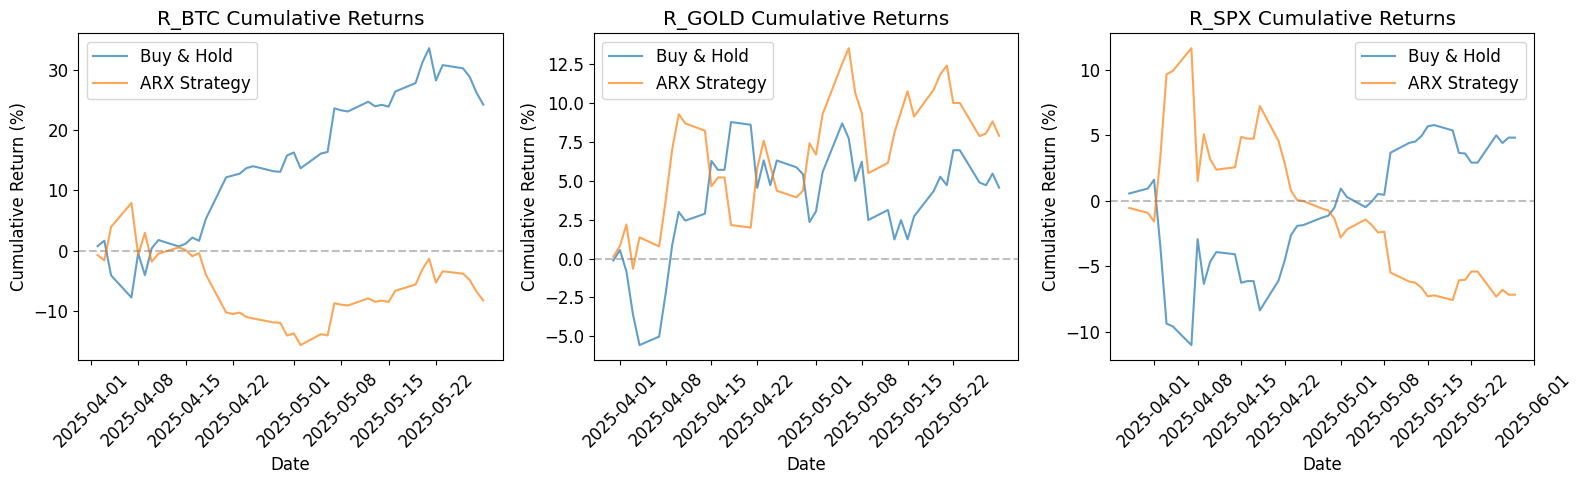


Cumulative Returns Summary:
  r_btc:
    Buy & Hold: 24.19%
    ARX Strategy: -8.26%
  r_gold:
    Buy & Hold: 4.55%
    ARX Strategy: 7.88%
  r_spx:
    Buy & Hold: 4.82%
    ARX Strategy: -7.17%


In [14]:
# Compute cumulative returns for each asset
cumulative_returns = {}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, target in enumerate(TARGET_COLS):
    preds_df = oos_predictions[target]
    
    # Trading signal: long if predicted return > 0, else short
    signals = np.sign(preds_df['y_pred'].values)
    actual_returns = preds_df['y_true'].values
    
    # Strategy returns
    strategy_returns = signals * actual_returns
    
    # Cumulative returns
    cum_buy_hold = np.cumprod(1 + actual_returns) - 1
    cum_strategy = np.cumprod(1 + strategy_returns) - 1
    
    cumulative_returns[target] = {
        'dates': preds_df.index,
        'buy_hold': cum_buy_hold,
        'strategy': cum_strategy,
        'final_buy_hold': cum_buy_hold[-1],
        'final_strategy': cum_strategy[-1],
    }
    
    # Plot
    ax = axes[idx]
    ax.plot(preds_df.index, cum_buy_hold * 100, label='Buy & Hold', alpha=0.7)
    ax.plot(preds_df.index, cum_strategy * 100, label='ARX Strategy', alpha=0.7)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'{target.upper()} Cumulative Returns')
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative Return (%)')
    ax.legend(loc='best')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'arx_baseline_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("\nCumulative Returns Summary:")
for target, data in cumulative_returns.items():
    print(f"  {target}:")
    print(f"    Buy & Hold: {data['final_buy_hold']*100:.2f}%")
    print(f"    ARX Strategy: {data['final_strategy']*100:.2f}%")

## Coefficient Analysis with Bootstrap Confidence Intervals

Analyze model coefficients with bootstrap-based statistical significance testing at multiple levels (1%, 5%, 10%).

In [16]:
# Bootstrap analysis for each asset
bootstrap_results = {}

for target in TARGET_COLS:
    print(f"\nBootstrap analysis for {target}...")
    
    # Get data from stored results
    X_design = baseline_results[target]['X_supervised']
    y_design = baseline_results[target]['y_supervised']
    pipeline = baseline_results[target]['fitted_pipeline']
    feature_names = baseline_results[target]['feature_names']
    
    # Run bootstrap
    ci_df = bootstrap_coefficient_ci(
        X=X_design.values,
        y=y_design.values,
        pipeline=pipeline,
        feature_names=feature_names,
        n_iter=500,  # Reduced for speed
        alpha_levels=[0.01, 0.05, 0.10],
    )
    
    bootstrap_results[target] = ci_df
    
    # Display significant features (index is the feature name)
    sig_features = ci_df[ci_df['stars'] != '']
    print(f"  Features significant at α=0.10 or better:")
    if len(sig_features) > 0:
        for feat_name in sig_features.index:
            row = sig_features.loc[feat_name]
            print(f"    {feat_name}: {row['coef']:.6f} (p={row['pvalue']:.4f}) {row['stars']}")
    else:
        print("    No significant features")


Bootstrap analysis for r_btc...
  Features significant at α=0.10 or better:
    No significant features

Bootstrap analysis for r_gold...
  Features significant at α=0.10 or better:
    ctl_dln_oil_lag1: 0.003040 (p=0.0680) *
    ctl_dln_oil_lag3: -0.005122 (p=0.0360) **

Bootstrap analysis for r_spx...
  Features significant at α=0.10 or better:
    No significant features


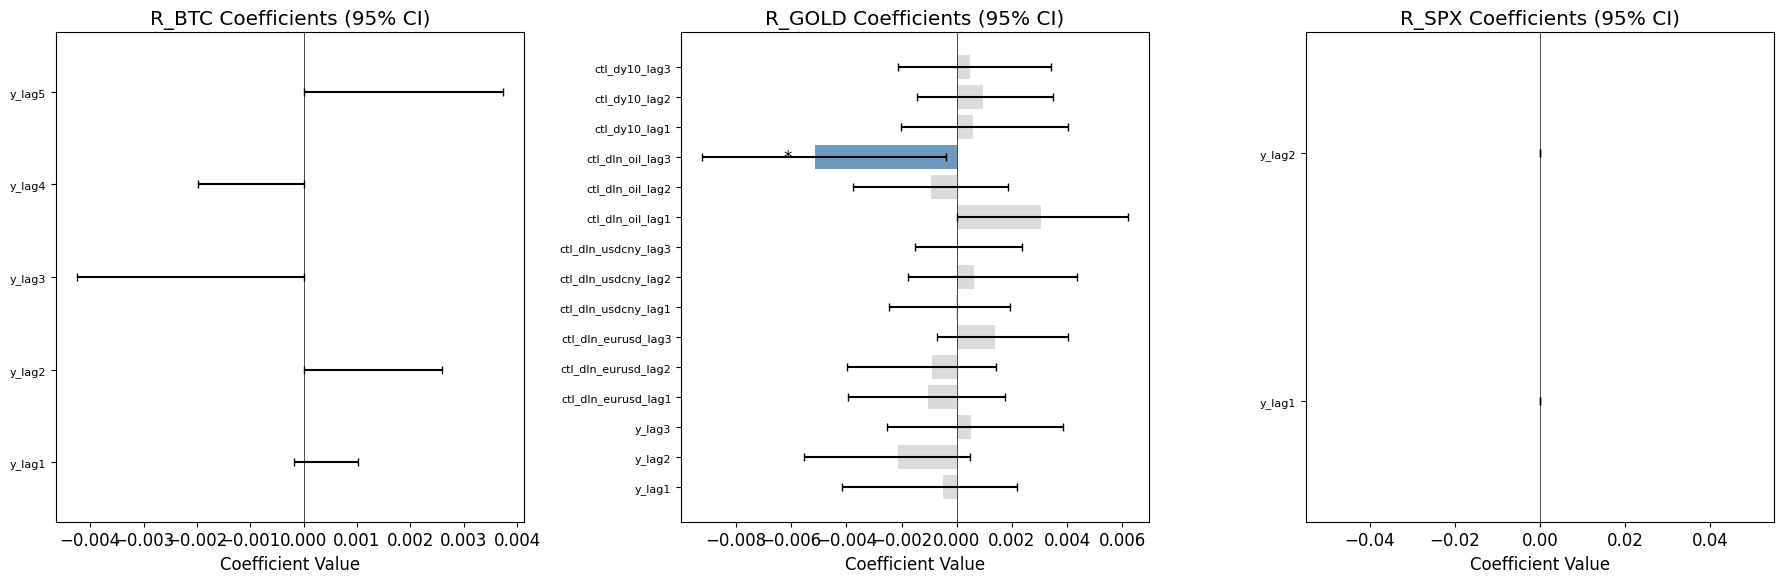

In [17]:
# Visualize coefficients with significance
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, target in enumerate(TARGET_COLS):
    ax = axes[idx]
    
    ci_df = bootstrap_results[target]
    features = list(ci_df.index)
    means = ci_df['coef'].values
    
    # Get 95% CI bounds
    ci_lower = ci_df['ci_lower_95'].values if 'ci_lower_95' in ci_df.columns else means - ci_df['se'].values * 1.96
    ci_upper = ci_df['ci_upper_95'].values if 'ci_upper_95' in ci_df.columns else means + ci_df['se'].values * 1.96
    significant = ci_df['sig_95'].values if 'sig_95' in ci_df.columns else [False] * len(means)
    
    # Error bars
    errors = [np.abs(means - ci_lower), np.abs(ci_upper - means)]
    
    # Colors based on significance
    colors = ['steelblue' if sig else 'lightgray' for sig in significant]
    
    y_pos = np.arange(len(features))
    ax.barh(y_pos, means, xerr=errors, color=colors, capsize=3, alpha=0.8)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features, fontsize=8)
    ax.set_xlabel('Coefficient Value')
    ax.set_title(f'{target.upper()} Coefficients (95% CI)')
    
    # Add significance markers
    for i, (sig, mean) in enumerate(zip(significant, means)):
        if sig:
            offset = 0.001 if mean > 0 else -0.001
            ax.annotate('*', (mean + offset, i), fontsize=12, ha='center', va='center')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'arx_baseline_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## Save Results

Save all baseline results to CSV files for later comparison with emotion-enhanced models.

In [18]:
# Save metrics summary
metrics_output = []
for target in TARGET_COLS:
    lags = baseline_results[target]['best_lags']
    cv = baseline_results[target]
    oos = oos_metrics[target]
    cum_ret = cumulative_returns[target]
    
    metrics_output.append({
        'asset': target,
        'model': 'ARX_baseline',
        'p': lags.ar_p,
        'q_controls': lags.q_controls,
        'cv_mae': cv['cv_mae'],
        'cv_rmse': cv['cv_rmse'],
        'oos_mae': oos['mae'],
        'oos_rmse': oos['rmse'],
        'oos_mape': oos['mape'],
        'oos_r2': oos['r2'],
        'dir_accuracy': oos['dir_acc'],
        'cum_return_buy_hold': cum_ret['final_buy_hold'],
        'cum_return_strategy': cum_ret['final_strategy'],
    })

metrics_output_df = pd.DataFrame(metrics_output)
metrics_output_df.to_csv(OUTPUT_DIR / 'arx_baseline_metrics.csv', index=False)
print(f"Saved metrics to {OUTPUT_DIR / 'arx_baseline_metrics.csv'}")

# Save predictions
for target in TARGET_COLS:
    oos_predictions[target].to_csv(OUTPUT_DIR / f'arx_baseline_predictions_{target}.csv')
print(f"Saved predictions to {OUTPUT_DIR}")

# Save bootstrap results
bootstrap_output = []
for target in TARGET_COLS:
    ci_df = bootstrap_results[target]
    for feat_name in ci_df.index:
        row = ci_df.loc[feat_name]
        bootstrap_output.append({
            'asset': target,
            'feature': feat_name,
            'coef': row['coef'],
            'se': row.get('se', np.nan),
            'pvalue': row.get('pvalue', np.nan),
            'stars': row.get('stars', ''),
            'ci_lower_95': row.get('ci_lower_95', np.nan),
            'ci_upper_95': row.get('ci_upper_95', np.nan),
            'sig_95': row.get('sig_95', False),
        })

bootstrap_df = pd.DataFrame(bootstrap_output)
bootstrap_df.to_csv(OUTPUT_DIR / 'arx_baseline_bootstrap.csv', index=False)
print(f"Saved bootstrap results to {OUTPUT_DIR / 'arx_baseline_bootstrap.csv'}")

print("\n✅ All baseline ARX results saved successfully!")

Saved metrics to /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim/arx_baseline_metrics.csv
Saved predictions to /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim
Saved bootstrap results to /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim/arx_baseline_bootstrap.csv

✅ All baseline ARX results saved successfully!
